In [13]:
# notebook: notebooks/evaluation.ipynb

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)
import re, warnings
warnings.filterwarnings("ignore")

# ── Recharger ────────────────────────────────────────────
df_test = pd.read_csv("../data/test.csv")
tfidf   = joblib.load("../models/tfidf.pkl")

KEYWORDS = ["ignore","bypass","jailbreak","forget","pretend",
            "roleplay","override","disregard","base64","system"]

def clean_text(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def manual_features(df):
    feats = pd.DataFrame()
    feats["text_len"]        = df["text"].str.len()
    feats["word_count"]      = df["text"].str.split().str.len()
    feats["has_keyword"]     = df["text"].str.lower().apply(lambda x: int(any(k in str(x) for k in KEYWORDS)))
    feats["has_base64"]      = df["text"].str.contains(r"[A-Za-z0-9+/]{20,}={0,2}", regex=True).astype(int)
    feats["uppercase_ratio"] = df["text"].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)),1))
    return feats

df_test["clean_text"] = df_test["text"].apply(clean_text)
X_test = hstack([tfidf.transform(df_test["clean_text"]), csr_matrix(manual_features(df_test).values)])
y_test = df_test["label"].values

In [6]:
#Charger tous les modèles + évaluer
model_files = {
    "Logistic Regression": "../models/logistic_regression.pkl",
    "Random Forest":       "../models/random_forest.pkl",
    "LinearSVC":           "../models/linearsvc.pkl",
    "Gradient Boosting":   "../models/gradient_boosting.pkl",
}

summary = []

for name, path in model_files.items():
    model = joblib.load(path)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    # ROC-AUC (decision_function ou predict_proba)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)
    auc = roc_auc_score(y_test, score)
    summary.append({"Modèle": name, "Accuracy": round(acc,4),
                    "F1-Score": round(f1,4), "ROC-AUC": round(auc,4)})
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=["Bénin","Malicieux"]))

df_results = pd.DataFrame(summary).sort_values("F1-Score", ascending=False)
print("\n📊 Tableau comparatif :\n")
print(df_results.to_string(index=False))


── Logistic Regression ──
              precision    recall  f1-score   support

       Bénin       0.97      0.90      0.93       390
   Malicieux       0.93      0.98      0.96       552

    accuracy                           0.95       942
   macro avg       0.95      0.94      0.95       942
weighted avg       0.95      0.95      0.95       942


── Random Forest ──
              precision    recall  f1-score   support

       Bénin       0.99      0.90      0.94       390
   Malicieux       0.94      0.99      0.96       552

    accuracy                           0.96       942
   macro avg       0.96      0.95      0.95       942
weighted avg       0.96      0.96      0.96       942


── LinearSVC ──
              precision    recall  f1-score   support

       Bénin       0.97      0.91      0.94       390
   Malicieux       0.94      0.98      0.96       552

    accuracy                           0.95       942
   macro avg       0.95      0.94      0.95       942
weighted 

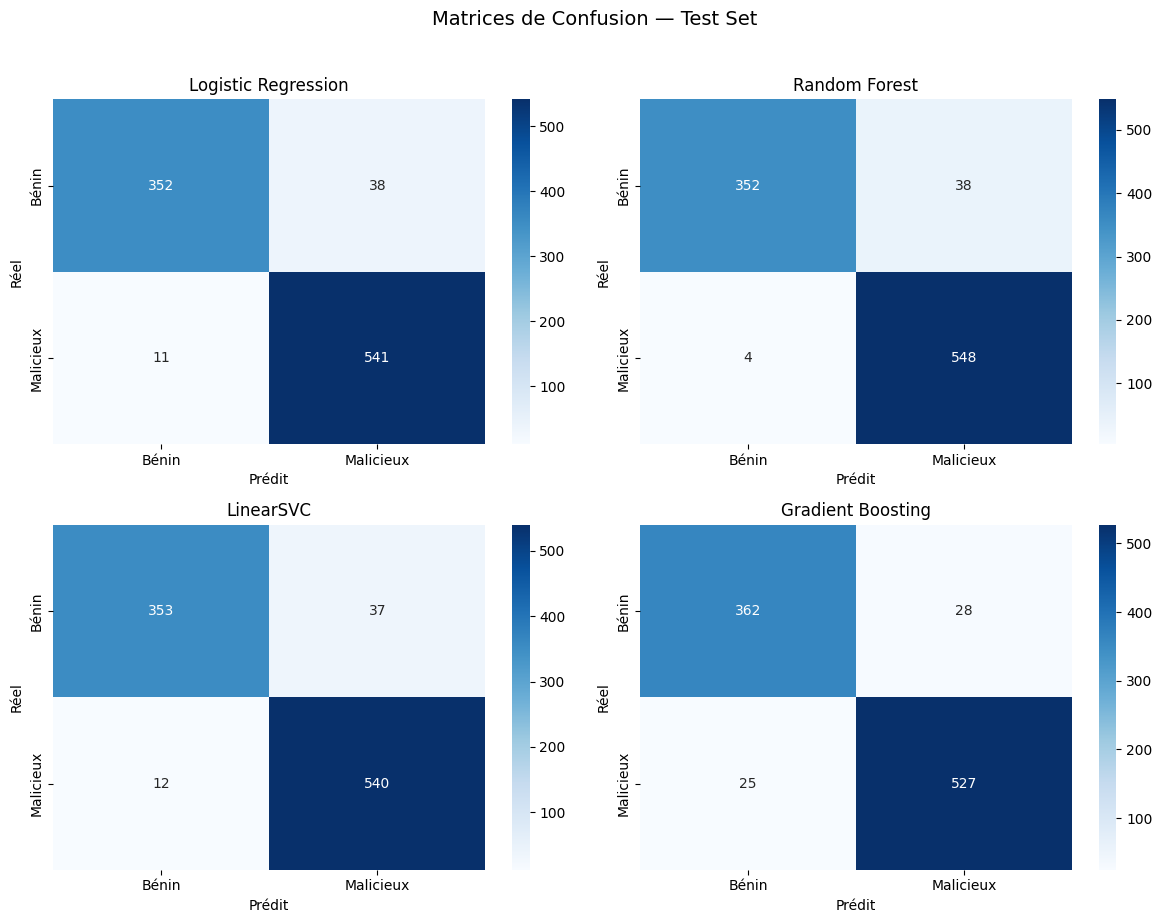

In [7]:
# Matrices de confusion 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (name, path) in enumerate(model_files.items()):
    model = joblib.load(path)
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i],
                cmap="Blues", xticklabels=["Bénin","Malicieux"],
                yticklabels=["Bénin","Malicieux"])
    axes[i].set_title(name)
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")

plt.suptitle("Matrices de Confusion — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig7_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

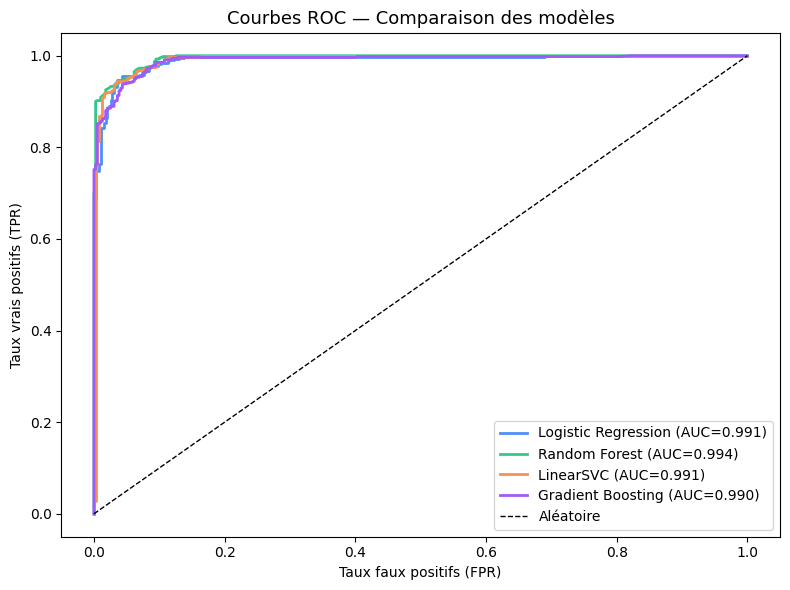

In [8]:
# Courbes ROC comparatives 
plt.figure(figsize=(8, 6))
colors = ["#4f8ef7", "#34c78a", "#f7914f", "#a259f7"]

for (name, path), color in zip(model_files.items(), colors):
    model = joblib.load(path)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--", lw=1, label="Aléatoire")
plt.xlabel("Taux faux positifs (FPR)")
plt.ylabel("Taux vrais positifs (TPR)")
plt.title("Courbes ROC — Comparaison des modèles", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/fig8_roc_curves.png", dpi=150)
plt.show()

In [11]:
model_files = {
    "Logistic Regression": "../models/logistic_regression.pkl",
    "Random Forest": "../models/random_forest.pkl",
    "LinearSVC": "../models/linearsvc.pkl",
    "Gradient Boosting": "../models/gradient_boosting.pkl"
}

results = []

for name, path in model_files.items():
    model = joblib.load(path)
    y_pred = model.predict(X_test)

    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, 
                                 model.predict_proba(X_test)[:,1] 
                                 if hasattr(model, "predict_proba") 
                                 else model.decision_function(X_test))
    })

df_results = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)

df_results

,Modèle,Accuracy,F1,ROC-AUC
0,Random Forest,0.955414,0.963093,0.994391
1,Logistic Regression,0.947983,0.956676,0.990524
2,LinearSVC,0.947983,0.956599,0.991397
3,Gradient Boosting,0.943737,0.952123,0.990041


In [12]:
# ── Analyse des erreurs ──────────────────────────────────
# Prendre AUTOMATIQUEMENT le meilleur modèle selon le F1-Score calculé plus haut
best_model_name = df_results.iloc[0]["Modèle"]
safe_name = best_model_name.lower().replace(" ", "_")
best_model = joblib.load(f"../models/{safe_name}.pkl")

print(f"📌 Meilleur modèle sélectionné : {best_model_name}")

y_pred = best_model.predict(X_test)

df_errors = df_test.copy()
df_errors["predicted"] = y_pred
df_errors["correct"]   = (y_pred == y_test)

# Faux positifs : bénin prédit malicieux
fp = df_errors[(df_errors["label"] == 0) & (df_errors["predicted"] == 1)]
# Faux négatifs : malicieux prédit bénin
fn = df_errors[(df_errors["label"] == 1) & (df_errors["predicted"] == 0)]

print(f"Faux positifs (bénins mal classifiés) : {len(fp)}")
print(f"Faux négatifs (attaques non détectées) : {len(fn)}")
print("\nExemples de faux négatifs (attaques non détectées) :")
print(fn[["text","category","severity"]].head(5).to_string())

📌 Meilleur modèle sélectionné : Random Forest
Faux positifs (bénins mal classifiés) : 38
Faux négatifs (attaques non détectées) : 4

Exemples de faux négatifs (attaques non détectées) :
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              